# Etapa 9 — Evaluación final fuera de tiempo

## Objetivo

Evaluar por única vez el modelo seleccionado sobre la semana 8, que representa datos futuros no utilizados durante la selección del modelo, los hiperparámetros ni el threshold.

## Protocolo bloqueado antes del test

- Pipeline seleccionado: `LogisticRegression_unweighted`.
- Artefacto fuente: `models/stage7_selected_model.joblib`.
- Hiperparámetros bloqueados: `C=1.0`, `solver="lbfgs"`, `max_iter=2000` y `random_state=42`.
- Variables predictoras: las 51 variables registradas en la política, conservando su orden exacto.
- Target de la tabla analítica: `pressure`.
- Definición del target: `pff_hurry OR pff_hit OR pff_sack`.
- El nombre `pressure_actual` se utiliza únicamente en el artefacto de predicciones de validación.
- Entrenamiento final: clonar el pipeline seleccionado y ejecutar un único `fit` con las semanas 1–7.
- Test final: semana 8, completamente excluida del entrenamiento.
- Sobre la semana 8 solo se ejecutará `predict_proba(X_test)[:, 1]`.
- Threshold bloqueado: `0.12485514806532311`.
- No se modificarán el modelo, las variables, los hiperparámetros, la calibración ni el threshold después de observar el test.
- Cualquier comparación entre las semanas 7 y 8 será exclusivamente descriptiva.

La apertura de la semana 8 fue autorizada expresamente antes de iniciar esta evaluación.

In [1]:
# ETAPA 9 · CELDA 2 — Configuración y validación del entorno

from pathlib import Path
import hashlib
import json
import sys

import joblib
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display


def find_project_root(start_path: Path) -> Path:
    """Localiza la raíz del proyecto desde la carpeta actual del kernel."""
    for candidate in (start_path, *start_path.parents):
        if (
            (candidate / "data").is_dir()
            and (candidate / "models").is_dir()
            and (candidate / "notebooks").is_dir()
            and (candidate / "reports").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "No se encontró la raíz del proyecto desde "
        f"{start_path}"
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())

PATHS = {
    "analytical_table": (
        PROJECT_ROOT / "data" / "processed" / "pass_rush_analytical_table.parquet"
    ),
    "selected_model": (
        PROJECT_ROOT / "models" / "stage7_selected_model.joblib"
    ),
    "stage7_validation_predictions": (
        PROJECT_ROOT / "reports" / "stage7_validation_predictions.parquet"
    ),
    "stage7_quality_report": (
        PROJECT_ROOT / "reports" / "stage7_quality_report.csv"
    ),
    "locked_policy": (
        PROJECT_ROOT / "reports" / "stage8_selected_policy.json"
    ),
    "stage8_quality_report": (
        PROJECT_ROOT / "reports" / "stage8_quality_report.csv"
    ),
}

environment_check = pd.DataFrame(
    [
        {
            "component": "Python",
            "observed": sys.version.split()[0],
            "expected": "3.14.0",
        },
        {
            "component": "NumPy",
            "observed": np.__version__,
            "expected": "2.5.2",
        },
        {
            "component": "pandas",
            "observed": pd.__version__,
            "expected": "3.0.5",
        },
        {
            "component": "scikit-learn",
            "observed": sklearn.__version__,
            "expected": "1.9.0",
        },
        {
            "component": "joblib",
            "observed": joblib.__version__,
            "expected": "1.5.3",
        },
    ]
)

environment_check["status"] = np.where(
    environment_check["observed"] == environment_check["expected"],
    "PASS",
    "FAIL",
)

artifact_inventory = pd.DataFrame(
    [
        {
            "artifact": name,
            "relative_path": str(path.relative_to(PROJECT_ROOT)),
            "exists": path.is_file(),
            "size_bytes": path.stat().st_size if path.is_file() else None,
        }
        for name, path in PATHS.items()
    ]
)

expected_python = (
    PROJECT_ROOT / ".venv" / "Scripts" / "python.exe"
).resolve()
observed_python = Path(sys.executable).resolve()

kernel_matches = (
    str(observed_python).casefold()
    == str(expected_python).casefold()
)

display(environment_check)
display(artifact_inventory)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Python observado: {observed_python}")
print(f"Python esperado:  {expected_python}")
print(f"Kernel correcto:  {kernel_matches}")

assert (environment_check["status"] == "PASS").all(), (
    "FAIL: alguna versión no coincide con el entorno validado."
)
assert artifact_inventory["exists"].all(), (
    "FAIL: falta al menos un artefacto requerido."
)
assert kernel_matches, (
    "FAIL: el notebook no está usando el Python de .venv."
)

print("STAGE 9 ENVIRONMENT AND ARTIFACT PRESENCE CHECK: PASS")

,component,observed,expected,status
0,Python,3.14.0,3.14.0,PASS
1,NumPy,2.5.2,2.5.2,PASS
2,pandas,3.0.5,3.0.5,PASS
3,scikit-learn,1.9.0,1.9.0,PASS
4,joblib,1.5.3,1.5.3,PASS


,artifact,relative_path,exists,size_bytes
0,analytical_table,data\processed\pass_rush_analytical_table.parquet,True,8917569
1,selected_model,models\stage7_selected_model.joblib,True,9649
2,stage7_validation_predictions,reports\stage7_validation_predictions.parquet,True,129661
3,stage7_quality_report,reports\stage7_quality_report.csv,True,2261
4,locked_policy,reports\stage8_selected_policy.json,True,5661
5,stage8_quality_report,reports\stage8_quality_report.csv,True,2341


PROJECT_ROOT: C:\Users\yvett\Downloads\nfl-pressure-prediction
Python observado: C:\Users\yvett\Downloads\nfl-pressure-prediction\.venv\Scripts\python.exe
Python esperado:  C:\Users\yvett\Downloads\nfl-pressure-prediction\.venv\Scripts\python.exe
Kernel correcto:  True
STAGE 9 ENVIRONMENT AND ARTIFACT PRESENCE CHECK: PASS


In [2]:
# ETAPA 9 · CELDA 3 — Integridad de los artefactos bloqueados

def calculate_sha256(file_path: Path) -> str:
    """Calcula la huella SHA-256 de un archivo sin modificarlo."""
    sha256 = hashlib.sha256()

    with file_path.open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            sha256.update(block)

    return sha256.hexdigest()


expected_hashes = {
    "selected_model": (
        "bbd5cf914cc56b3688ea55f44f79f683d954312a8346a54b13ac738c9be12a21"
    ),
    "stage7_validation_predictions": (
        "57d2f95f6d7b668bf200cd4bfa63f488070505ba8e97d33e76c83e250da7a7d1"
    ),
    "locked_policy": (
        "52e6658ea7ec42e74f000cc42fdbd51c46a22fe55849e5c24c76e6f42c61828c"
    ),
    "stage8_quality_report": (
        "71e6fbcd96f93bbc24fcac270aecb9c82085b96375b96819b1d90d7d067d15c6"
    ),
}

integrity_check = pd.DataFrame(
    [
        {
            "artifact": artifact,
            "expected_sha256": expected_hash,
            "observed_sha256": calculate_sha256(PATHS[artifact]),
        }
        for artifact, expected_hash in expected_hashes.items()
    ]
)

integrity_check["status"] = np.where(
    integrity_check["observed_sha256"]
    == integrity_check["expected_sha256"],
    "PASS",
    "FAIL",
)

display(integrity_check)

assert (integrity_check["status"] == "PASS").all(), (
    "FAIL: al menos un artefacto no coincide con su huella bloqueada."
)

print("STAGE 9 LOCKED ARTIFACT INTEGRITY CHECK: PASS")

,artifact,expected_sha256,observed_sha256,status
0,selected_model,bbd5cf914cc56b3688ea55f44f79f683d954312a8346a5...,bbd5cf914cc56b3688ea55f44f79f683d954312a8346a5...,PASS
1,stage7_validation_predictions,57d2f95f6d7b668bf200cd4bfa63f488070505ba8e97d3...,57d2f95f6d7b668bf200cd4bfa63f488070505ba8e97d3...,PASS
2,locked_policy,52e6658ea7ec42e74f000cc42fdbd51c46a22fe55849e5...,52e6658ea7ec42e74f000cc42fdbd51c46a22fe55849e5...,PASS
3,stage8_quality_report,71e6fbcd96f93bbc24fcac270aecb9c82085b96375b968...,71e6fbcd96f93bbc24fcac270aecb9c82085b96375b968...,PASS


STAGE 9 LOCKED ARTIFACT INTEGRITY CHECK: PASS


In [3]:
# ETAPA 9 · CELDA 4 — Validación del modelo y protocolo bloqueado

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


with PATHS["locked_policy"].open("r", encoding="utf-8") as file:
    locked_policy = json.load(file)

stage7_selected_pipeline = joblib.load(PATHS["selected_model"])

stage7_quality_report = pd.read_csv(
    PATHS["stage7_quality_report"]
)
stage8_quality_report = pd.read_csv(
    PATHS["stage8_quality_report"]
)

model_contract = locked_policy["model_contract"]
target_contract = locked_policy["target_contract"]
threshold_contract = locked_policy["threshold_contract"]
training_recipe = locked_policy["final_training_recipe"]
evaluation_protocol = locked_policy["final_evaluation_protocol"]

ordered_feature_names = model_contract["ordered_feature_names"]
locked_threshold = float(threshold_contract["threshold"])

final_estimator = stage7_selected_pipeline.steps[-1][1]
estimator_parameters = final_estimator.get_params()

model_feature_names = list(
    stage7_selected_pipeline.feature_names_in_
)

post_test_changes_locked = all(
    evaluation_protocol[field] is False
    for field in [
        "allow_calibration_after_test",
        "allow_feature_changes_after_test",
        "allow_model_changes_after_test",
        "allow_threshold_changes_after_test",
    ]
)

protocol_checks = []


def register_check(check_id, area, observed, expected, condition):
    protocol_checks.append(
        {
            "check_id": check_id,
            "area": area,
            "observed": str(observed),
            "expected": str(expected),
            "status": "PASS" if condition else "FAIL",
        }
    )


register_check(
    "ST9-01",
    "Policy status",
    locked_policy["status"],
    "locked_before_test_evaluation",
    locked_policy["status"] == "locked_before_test_evaluation",
)

register_check(
    "ST9-02",
    "Week 8 initial state",
    locked_policy["week_8_status"],
    "sealed_not_accessed",
    locked_policy["week_8_status"] == "sealed_not_accessed",
)

register_check(
    "ST9-03",
    "Pipeline class",
    type(stage7_selected_pipeline).__name__,
    "Pipeline",
    isinstance(stage7_selected_pipeline, Pipeline),
)

register_check(
    "ST9-04",
    "Final estimator",
    type(final_estimator).__name__,
    "LogisticRegression",
    isinstance(final_estimator, LogisticRegression),
)

observed_hyperparameters = {
    "C": estimator_parameters["C"],
    "class_weight": estimator_parameters["class_weight"],
    "max_iter": estimator_parameters["max_iter"],
    "random_state": estimator_parameters["random_state"],
    "solver": estimator_parameters["solver"],
}

register_check(
    "ST9-05",
    "Hyperparameters",
    observed_hyperparameters,
    model_contract["hyperparameters"],
    observed_hyperparameters == model_contract["hyperparameters"],
)

register_check(
    "ST9-06",
    "Feature count",
    len(ordered_feature_names),
    51,
    len(ordered_feature_names) == 51,
)

register_check(
    "ST9-07",
    "Feature uniqueness",
    len(set(ordered_feature_names)),
    51,
    len(set(ordered_feature_names)) == 51,
)

register_check(
    "ST9-08",
    "Feature order",
    model_feature_names == ordered_feature_names,
    True,
    model_feature_names == ordered_feature_names,
)

register_check(
    "ST9-09",
    "Analytical target",
    target_contract["analytical_target"],
    "pressure",
    target_contract["analytical_target"] == "pressure",
)

register_check(
    "ST9-10",
    "Final training weeks",
    training_recipe["training_weeks"],
    list(range(1, 8)),
    training_recipe["training_weeks"] == list(range(1, 8)),
)

register_check(
    "ST9-11",
    "Final test week",
    training_recipe["test_week"],
    8,
    training_recipe["test_week"] == 8,
)

register_check(
    "ST9-12",
    "Single final fit",
    training_recipe["fit_once"],
    True,
    training_recipe["fit_once"] is True,
)

register_check(
    "ST9-13",
    "Test excluded from fit",
    training_recipe["test_data_used_during_fit"],
    False,
    training_recipe["test_data_used_during_fit"] is False,
)

register_check(
    "ST9-14",
    "Locked threshold",
    locked_threshold,
    0.12485514806532311,
    np.isclose(
        locked_threshold,
        0.12485514806532311,
        rtol=0.0,
        atol=1e-15,
    ),
)

register_check(
    "ST9-15",
    "Post-test changes",
    post_test_changes_locked,
    True,
    post_test_changes_locked,
)

register_check(
    "ST9-16",
    "Stage 7 quality",
    (
        len(stage7_quality_report),
        stage7_quality_report["status"].eq("PASS").sum(),
    ),
    (16, 16),
    (
        len(stage7_quality_report) == 16
        and stage7_quality_report["status"].eq("PASS").all()
    ),
)

register_check(
    "ST9-17",
    "Stage 8 quality",
    (
        len(stage8_quality_report),
        stage8_quality_report["status"].eq("PASS").sum(),
    ),
    (20, 20),
    (
        len(stage8_quality_report) == 20
        and stage8_quality_report["status"].eq("PASS").all()
    ),
)

protocol_check_report = pd.DataFrame(protocol_checks)

display(protocol_check_report)

assert protocol_check_report["status"].eq("PASS").all(), (
    "FAIL: el modelo o el protocolo no coincide con el checkpoint."
)

print("STAGE 9 LOCKED MODEL AND PROTOCOL CHECK: PASS")

,check_id,area,observed,expected,status
0,ST9-01,Policy status,locked_before_test_evaluation,locked_before_test_evaluation,PASS
1,ST9-02,Week 8 initial state,sealed_not_accessed,sealed_not_accessed,PASS
2,ST9-03,Pipeline class,Pipeline,Pipeline,PASS
3,ST9-04,Final estimator,LogisticRegression,LogisticRegression,PASS
4,ST9-05,Hyperparameters,"{'C': 1.0, 'class_weight': None, 'max_iter': 2...","{'C': 1.0, 'class_weight': None, 'max_iter': 2...",PASS
5,ST9-06,Feature count,51,51,PASS
6,ST9-07,Feature uniqueness,51,51,PASS
7,ST9-08,Feature order,True,True,PASS
8,ST9-09,Analytical target,pressure,pressure,PASS
9,ST9-10,Final training weeks,"[1, 2, 3, 4, 5, 6, 7]","[1, 2, 3, 4, 5, 6, 7]",PASS


STAGE 9 LOCKED MODEL AND PROTOCOL CHECK: PASS


In [4]:
# ETAPA 9 · CELDA 5 — Auditoría de la tabla analítica sin materializar el test

import pyarrow.parquet as pq
from pandas.api.types import is_numeric_dtype


analytical_parquet = pq.ParquetFile(PATHS["analytical_table"])

parquet_total_rows = analytical_parquet.metadata.num_rows
parquet_column_names = analytical_parquet.schema_arrow.names
parquet_total_columns = len(parquet_column_names)

development_table = pd.read_parquet(
    PATHS["analytical_table"],
    filters=[("actual_week", "<=", 7)],
)

key_columns = [
    "gameId",
    "playId",
    "pass_rusher_nfl_id",
]

categorical_predictors = model_contract["categorical_predictors"]
numeric_predictors = [
    feature
    for feature in ordered_feature_names
    if feature not in categorical_predictors
]

expected_week_counts = pd.DataFrame(
    {
        "actual_week": [1, 2, 3, 4, 5, 6, 7],
        "expected_rows": [4988, 4498, 4809, 4733, 4681, 4241, 3865],
        "expected_positives": [598, 521, 606, 557, 528, 473, 427],
    }
)

observed_week_counts = (
    development_table
    .groupby("actual_week", as_index=False)
    .agg(
        observed_rows=("pressure", "size"),
        observed_positives=("pressure", "sum"),
    )
)

observed_week_counts["observed_positives"] = (
    observed_week_counts["observed_positives"].astype(int)
)

week_count_check = expected_week_counts.merge(
    observed_week_counts,
    on="actual_week",
    how="outer",
    validate="one_to_one",
)

week_count_check["status"] = np.where(
    (
        week_count_check["expected_rows"]
        == week_count_check["observed_rows"]
    )
    & (
        week_count_check["expected_positives"]
        == week_count_check["observed_positives"]
    ),
    "PASS",
    "FAIL",
)

missing_model_features = sorted(
    set(ordered_feature_names) - set(development_table.columns)
)

duplicate_key_count = int(
    development_table.duplicated(key_columns).sum()
)

missing_model_values = int(
    development_table[
        ordered_feature_names + ["pressure"]
    ].isna().sum().sum()
)

numeric_type_check = all(
    is_numeric_dtype(development_table[column])
    for column in numeric_predictors
)

forbidden_identifiers = {
    "gameId",
    "playId",
    "nflId",
    "pass_rusher_nfl_id",
}

development_checks = []


def register_development_check(
    check_id,
    area,
    observed,
    expected,
    condition,
):
    development_checks.append(
        {
            "check_id": check_id,
            "area": area,
            "observed": str(observed),
            "expected": str(expected),
            "status": "PASS" if condition else "FAIL",
        }
    )


register_development_check(
    "ST9-18",
    "Parquet total rows",
    parquet_total_rows,
    36259,
    parquet_total_rows == 36259,
)

register_development_check(
    "ST9-19",
    "Parquet total columns",
    parquet_total_columns,
    70,
    parquet_total_columns == 70,
)

register_development_check(
    "ST9-20",
    "Development shape",
    development_table.shape,
    (31815, 70),
    development_table.shape == (31815, 70),
)

register_development_check(
    "ST9-21",
    "Development weeks",
    sorted(development_table["actual_week"].unique().tolist()),
    list(range(1, 8)),
    sorted(
        development_table["actual_week"].unique().tolist()
    ) == list(range(1, 8)),
)

register_development_check(
    "ST9-22",
    "Development positives",
    int(development_table["pressure"].sum()),
    3710,
    int(development_table["pressure"].sum()) == 3710,
)

register_development_check(
    "ST9-23",
    "Development plays",
    development_table[
        ["gameId", "playId"]
    ].drop_duplicates().shape[0],
    7500,
    development_table[
        ["gameId", "playId"]
    ].drop_duplicates().shape[0] == 7500,
)

register_development_check(
    "ST9-24",
    "Duplicate rusher-play keys",
    duplicate_key_count,
    0,
    duplicate_key_count == 0,
)

register_development_check(
    "ST9-25",
    "Target classes",
    sorted(development_table["pressure"].unique().tolist()),
    [0, 1],
    sorted(
        development_table["pressure"].unique().tolist()
    ) == [0, 1],
)

register_development_check(
    "ST9-26",
    "Missing model values",
    missing_model_values,
    0,
    missing_model_values == 0,
)

register_development_check(
    "ST9-27",
    "Model features present",
    len(missing_model_features),
    0,
    len(missing_model_features) == 0,
)

register_development_check(
    "ST9-28",
    "Numeric predictor types",
    numeric_type_check,
    True,
    numeric_type_check,
)

register_development_check(
    "ST9-29",
    "Identifiers excluded",
    sorted(
        forbidden_identifiers.intersection(
            ordered_feature_names
        )
    ),
    [],
    forbidden_identifiers.isdisjoint(
        ordered_feature_names
    ),
)

register_development_check(
    "ST9-30",
    "Week 8 rows in memory",
    int(
        development_table["actual_week"]
        .eq(8)
        .sum()
    ),
    0,
    not development_table["actual_week"].eq(8).any(),
)

development_check_report = pd.DataFrame(
    development_checks
)

display(week_count_check)
display(development_check_report)

assert week_count_check["status"].eq("PASS").all(), (
    "FAIL: los conteos semanales no coinciden."
)
assert development_check_report["status"].eq("PASS").all(), (
    "FAIL: la tabla regenerada no cumple el contrato."
)

print("STAGE 9 DEVELOPMENT DATA CONTRACT CHECK: PASS")
print("WEEK 8 ROWS MATERIALIZED IN MEMORY: 0")

,actual_week,expected_rows,expected_positives,observed_rows,observed_positives,status
0,1,4988,598,4988,598,PASS
1,2,4498,521,4498,521,PASS
2,3,4809,606,4809,606,PASS
3,4,4733,557,4733,557,PASS
4,5,4681,528,4681,528,PASS
5,6,4241,473,4241,473,PASS
6,7,3865,427,3865,427,PASS


,check_id,area,observed,expected,status
0,ST9-18,Parquet total rows,36259,36259,PASS
1,ST9-19,Parquet total columns,70,70,PASS
2,ST9-20,Development shape,"(31815, 70)","(31815, 70)",PASS
3,ST9-21,Development weeks,"[1, 2, 3, 4, 5, 6, 7]","[1, 2, 3, 4, 5, 6, 7]",PASS
4,ST9-22,Development positives,3710,3710,PASS
5,ST9-23,Development plays,7500,7500,PASS
6,ST9-24,Duplicate rusher-play keys,0,0,PASS
7,ST9-25,Target classes,"[0, 1]","[0, 1]",PASS
8,ST9-26,Missing model values,0,0,PASS
9,ST9-27,Model features present,0,0,PASS


STAGE 9 DEVELOPMENT DATA CONTRACT CHECK: PASS
WEEK 8 ROWS MATERIALIZED IN MEMORY: 0


In [5]:
# ETAPA 9 · CELDA 6 — Alineación con el checkpoint de validación

stage7_validation_predictions = pd.read_parquet(
    PATHS["stage7_validation_predictions"]
)

validation_schema = pd.DataFrame(
    {
        "column": stage7_validation_predictions.columns,
        "dtype": [
            str(dtype)
            for dtype in stage7_validation_predictions.dtypes
        ],
        "missing_values": [
            int(stage7_validation_predictions[column].isna().sum())
            for column in stage7_validation_predictions.columns
        ],
    }
)

probability_candidates = [
    column
    for column in stage7_validation_predictions.columns
    if (
        "prob" in column.lower()
        and is_numeric_dtype(
            stage7_validation_predictions[column]
        )
    )
]

display(validation_schema)

print(
    "Validation artifact shape:",
    stage7_validation_predictions.shape,
)
print(
    "Probability candidates:",
    probability_candidates,
)

selected_model_name = model_contract["selected_model"]

assert selected_model_name == "LogisticRegression_unweighted", (
    "FAIL: cambió el modelo seleccionado."
)

validation_probability_column = (
    "probability_logistic_regression"
)

assert (
    validation_probability_column
    in stage7_validation_predictions.columns
), "FAIL: falta la probabilidad del modelo seleccionado."

development_week_7 = (
    development_table.loc[
        development_table["actual_week"].eq(7),
        key_columns + ordered_feature_names + ["pressure"],
    ]
    .copy()
)

validation_alignment = development_week_7.merge(
    stage7_validation_predictions[
        key_columns
        + [
            "actual_week",
            "pressure_actual",
            validation_probability_column,
        ]
    ],
    on=key_columns,
    how="outer",
    validate="one_to_one",
    indicator=True,
)

validation_checkpoint_checks = []


def register_validation_check(
    check_id,
    area,
    observed,
    expected,
    condition,
):
    validation_checkpoint_checks.append(
        {
            "check_id": check_id,
            "area": area,
            "observed": str(observed),
            "expected": str(expected),
            "status": "PASS" if condition else "FAIL",
        }
    )


register_validation_check(
    "ST9-31",
    "Validation rows",
    len(stage7_validation_predictions),
    3865,
    len(stage7_validation_predictions) == 3865,
)

register_validation_check(
    "ST9-32",
    "Validation weeks",
    sorted(
        stage7_validation_predictions[
            "actual_week"
        ].unique().tolist()
    ),
    [7],
    sorted(
        stage7_validation_predictions[
            "actual_week"
        ].unique().tolist()
    ) == [7],
)

register_validation_check(
    "ST9-33",
    "Validation plays",
    stage7_validation_predictions[
        ["gameId", "playId"]
    ].drop_duplicates().shape[0],
    913,
    stage7_validation_predictions[
        ["gameId", "playId"]
    ].drop_duplicates().shape[0] == 913,
)

register_validation_check(
    "ST9-34",
    "Validation positives",
    int(
        stage7_validation_predictions[
            "pressure_actual"
        ].sum()
    ),
    427,
    int(
        stage7_validation_predictions[
            "pressure_actual"
        ].sum()
    ) == 427,
)

register_validation_check(
    "ST9-35",
    "Duplicate validation keys",
    int(
        stage7_validation_predictions
        .duplicated(key_columns)
        .sum()
    ),
    0,
    not stage7_validation_predictions
    .duplicated(key_columns)
    .any(),
)

register_validation_check(
    "ST9-36",
    "Probability column",
    validation_probability_column,
    "probability_logistic_regression",
    validation_probability_column
    == "probability_logistic_regression",
)

probability_values = stage7_validation_predictions[
    validation_probability_column
].to_numpy()

register_validation_check(
    "ST9-37",
    "Finite probabilities",
    bool(np.isfinite(probability_values).all()),
    True,
    bool(np.isfinite(probability_values).all()),
)

register_validation_check(
    "ST9-38",
    "Probability range",
    (
        float(probability_values.min()),
        float(probability_values.max()),
    ),
    "within [0, 1]",
    bool(
        (
            (probability_values >= 0.0)
            & (probability_values <= 1.0)
        ).all()
    ),
)

register_validation_check(
    "ST9-39",
    "Key alignment",
    validation_alignment["_merge"]
    .value_counts()
    .to_dict(),
    {"both": 3865},
    validation_alignment["_merge"].eq("both").all(),
)

target_alignment = bool(
    (
        validation_alignment["pressure"].astype(int)
        == validation_alignment["pressure_actual"].astype(int)
    ).all()
)

register_validation_check(
    "ST9-40",
    "Target alignment",
    target_alignment,
    True,
    target_alignment,
)

validation_checkpoint_report = pd.DataFrame(
    validation_checkpoint_checks
)

display(validation_checkpoint_report)

assert validation_checkpoint_report["status"].eq("PASS").all(), (
    "FAIL: la semana 7 no coincide con el checkpoint aprobado."
)

print("STAGE 9 VALIDATION CHECKPOINT ALIGNMENT: PASS")
print(
    "LOCKED PROBABILITY COLUMN:",
    validation_probability_column,
)
print("WEEK 8 ROWS MATERIALIZED IN MEMORY: 0")

,column,dtype,missing_values
0,actual_week,Int64,0
1,gameId,int64,0
2,playId,int64,0
3,pass_rusher_nfl_id,int64,0
4,pressure_actual,int8,0
5,probability_logistic_regression,float64,0
6,probability_extra_trees,float64,0
7,probability_hist_gradient_boosting,float64,0


Validation artifact shape: (3865, 8)
Probability candidates: ['probability_logistic_regression', 'probability_extra_trees', 'probability_hist_gradient_boosting']


,check_id,area,observed,expected,status
0,ST9-31,Validation rows,3865,3865,PASS
1,ST9-32,Validation weeks,[7],[7],PASS
2,ST9-33,Validation plays,913,913,PASS
3,ST9-34,Validation positives,427,427,PASS
4,ST9-35,Duplicate validation keys,0,0,PASS
5,ST9-36,Probability column,probability_logistic_regression,probability_logistic_regression,PASS
6,ST9-37,Finite probabilities,True,True,PASS
7,ST9-38,Probability range,"(0.02825845903634364, 0.44986998289681784)","within [0, 1]",PASS
8,ST9-39,Key alignment,"{'both': 3865, 'left_only': 0, 'right_only': 0}",{'both': 3865},PASS
9,ST9-40,Target alignment,True,True,PASS


STAGE 9 VALIDATION CHECKPOINT ALIGNMENT: PASS
LOCKED PROBABILITY COLUMN: probability_logistic_regression
WEEK 8 ROWS MATERIALIZED IN MEMORY: 0


In [6]:
# ETAPA 9 · CELDA 7 — Reproducción del checkpoint de semana 7

from sklearn.metrics import (
    average_precision_score,
    log_loss,
    roc_auc_score,
)


week_7_model_input = development_week_7[
    ordered_feature_names
]

week_7_target = (
    development_week_7["pressure"]
    .astype(int)
    .to_numpy()
)

week_7_reproduced_probability = (
    stage7_selected_pipeline
    .predict_proba(week_7_model_input)[:, 1]
)

reproduced_validation = (
    development_week_7[key_columns]
    .copy()
)

reproduced_validation[
    "reproduced_probability"
] = week_7_reproduced_probability

probability_reproduction = reproduced_validation.merge(
    stage7_validation_predictions[
        key_columns + [validation_probability_column]
    ],
    on=key_columns,
    how="outer",
    validate="one_to_one",
    indicator=True,
)

probability_reproduction["absolute_difference"] = (
    probability_reproduction["reproduced_probability"]
    - probability_reproduction[
        validation_probability_column
    ]
).abs()

maximum_absolute_difference = float(
    probability_reproduction[
        "absolute_difference"
    ].max()
)

week_7_reproduced_metrics = {
    "average_precision": average_precision_score(
        week_7_target,
        week_7_reproduced_probability,
    ),
    "roc_auc": roc_auc_score(
        week_7_target,
        week_7_reproduced_probability,
    ),
    "log_loss": log_loss(
        week_7_target,
        week_7_reproduced_probability,
        labels=[0, 1],
    ),
}

expected_validation_metrics = {
    "average_precision": 0.151899,
    "roc_auc": 0.600006,
    "log_loss": 0.342382,
}

metric_reproduction = pd.DataFrame(
    [
        {
            "metric": metric,
            "observed": observed,
            "expected_rounded": expected_validation_metrics[metric],
            "observed_rounded": round(observed, 6),
            "status": (
                "PASS"
                if np.isclose(
                    observed,
                    expected_validation_metrics[metric],
                    rtol=0.0,
                    atol=5e-7,
                )
                else "FAIL"
            ),
        }
        for metric, observed
        in week_7_reproduced_metrics.items()
    ]
)

probability_reproduction_check = pd.DataFrame(
    [
        {
            "check_id": "ST9-41",
            "area": "Reproduced rows",
            "observed": len(probability_reproduction),
            "expected": 3865,
            "status": (
                "PASS"
                if len(probability_reproduction) == 3865
                else "FAIL"
            ),
        },
        {
            "check_id": "ST9-42",
            "area": "Reproduced key alignment",
            "observed": (
                probability_reproduction["_merge"]
                .value_counts()
                .to_dict()
            ),
            "expected": {"both": 3865},
            "status": (
                "PASS"
                if probability_reproduction[
                    "_merge"
                ].eq("both").all()
                else "FAIL"
            ),
        },
        {
            "check_id": "ST9-43",
            "area": "Maximum probability difference",
            "observed": maximum_absolute_difference,
            "expected": "<= 1e-12",
            "status": (
                "PASS"
                if maximum_absolute_difference <= 1e-12
                else "FAIL"
            ),
        },
    ]
)

display(probability_reproduction_check)
display(metric_reproduction)

assert probability_reproduction_check[
    "status"
].eq("PASS").all(), (
    "FAIL: las probabilidades no coinciden con el checkpoint."
)

assert metric_reproduction[
    "status"
].eq("PASS").all(), (
    "FAIL: las métricas de semana 7 no fueron reproducidas."
)

print("STAGE 9 VALIDATION PROBABILITY REPRODUCTION: PASS")
print(
    "MAXIMUM ABSOLUTE PROBABILITY DIFFERENCE:",
    f"{maximum_absolute_difference:.16e}",
)
print("WEEK 8 ROWS MATERIALIZED IN MEMORY: 0")

,check_id,area,observed,expected,status
0,ST9-41,Reproduced rows,3865,3865,PASS
1,ST9-42,Reproduced key alignment,"{'both': 3865, 'left_only': 0, 'right_only': 0}",{'both': 3865},PASS
2,ST9-43,Maximum probability difference,0.0,<= 1e-12,PASS


,metric,observed,expected_rounded,observed_rounded,status
0,average_precision,0.151899,0.151899,0.151899,PASS
1,roc_auc,0.600006,0.600006,0.600006,PASS
2,log_loss,0.342382,0.342382,0.342382,PASS


STAGE 9 VALIDATION PROBABILITY REPRODUCTION: PASS
MAXIMUM ABSOLUTE PROBABILITY DIFFERENCE: 0.0000000000000000e+00
WEEK 8 ROWS MATERIALIZED IN MEMORY: 0


In [7]:
# ETAPA 9 · CELDA 8 — Entrenamiento final bloqueado con semanas 1–7

from sklearn.base import clone
from sklearn.utils.validation import check_is_fitted
import time


if globals().get("final_fit_completed", False):
    raise RuntimeError(
        "El entrenamiento final ya fue ejecutado en este kernel. "
        "No se permite repetirlo."
    )

X_final_train = development_table[
    ordered_feature_names
].copy()

y_final_train = (
    development_table["pressure"]
    .astype(int)
    .copy()
)

final_training_weeks = sorted(
    development_table["actual_week"]
    .unique()
    .tolist()
)

assert final_training_weeks == list(range(1, 8)), (
    "FAIL: el entrenamiento final no contiene exactamente semanas 1–7."
)
assert not development_table["actual_week"].eq(8).any(), (
    "FAIL: semana 8 apareció dentro del entrenamiento."
)
assert X_final_train.shape == (31815, 51), (
    "FAIL: forma inesperada para X_final_train."
)
assert len(y_final_train) == 31815, (
    "FAIL: longitud inesperada para y_final_train."
)
assert int(y_final_train.sum()) == 3710, (
    "FAIL: positivos inesperados en y_final_train."
)

final_pressure_pipeline = clone(
    stage7_selected_pipeline
)

assert final_pressure_pipeline is not stage7_selected_pipeline
assert isinstance(final_pressure_pipeline, Pipeline)

final_fit_start = time.perf_counter()

final_pressure_pipeline.fit(
    X_final_train,
    y_final_train,
)

final_fit_seconds = time.perf_counter() - final_fit_start
final_fit_completed = True

check_is_fitted(final_pressure_pipeline)

final_fitted_estimator = (
    final_pressure_pipeline.steps[-1][1]
)

final_estimator_parameters = (
    final_fitted_estimator.get_params()
)

final_observed_hyperparameters = {
    "C": final_estimator_parameters["C"],
    "class_weight": final_estimator_parameters["class_weight"],
    "max_iter": final_estimator_parameters["max_iter"],
    "random_state": final_estimator_parameters["random_state"],
    "solver": final_estimator_parameters["solver"],
}

final_training_check = pd.DataFrame(
    [
        {
            "check_id": "ST9-44",
            "area": "Training weeks",
            "observed": str(final_training_weeks),
            "expected": str(list(range(1, 8))),
            "status": "PASS",
        },
        {
            "check_id": "ST9-45",
            "area": "Training rows",
            "observed": len(X_final_train),
            "expected": 31815,
            "status": (
                "PASS"
                if len(X_final_train) == 31815
                else "FAIL"
            ),
        },
        {
            "check_id": "ST9-46",
            "area": "Training positives",
            "observed": int(y_final_train.sum()),
            "expected": 3710,
            "status": (
                "PASS"
                if int(y_final_train.sum()) == 3710
                else "FAIL"
            ),
        },
        {
            "check_id": "ST9-47",
            "area": "Training feature count",
            "observed": X_final_train.shape[1],
            "expected": 51,
            "status": (
                "PASS"
                if X_final_train.shape[1] == 51
                else "FAIL"
            ),
        },
        {
            "check_id": "ST9-48",
            "area": "Final feature order",
            "observed": (
                list(final_pressure_pipeline.feature_names_in_)
                == ordered_feature_names
            ),
            "expected": True,
            "status": (
                "PASS"
                if list(
                    final_pressure_pipeline.feature_names_in_
                ) == ordered_feature_names
                else "FAIL"
            ),
        },
        {
            "check_id": "ST9-49",
            "area": "Final hyperparameters",
            "observed": str(final_observed_hyperparameters),
            "expected": str(model_contract["hyperparameters"]),
            "status": (
                "PASS"
                if final_observed_hyperparameters
                == model_contract["hyperparameters"]
                else "FAIL"
            ),
        },
        {
            "check_id": "ST9-50",
            "area": "Test rows used during fit",
            "observed": 0,
            "expected": 0,
            "status": "PASS",
        },
    ]
)

display(final_training_check)

assert final_training_check["status"].eq("PASS").all(), (
    "FAIL: el entrenamiento final no respetó el protocolo."
)

print("STAGE 9 FINAL TRAINING ON WEEKS 1–7: PASS")
print(
    "FINAL FIT DURATION (SECONDS):",
    f"{final_fit_seconds:.3f}",
)
print(
    "LOGISTIC ITERATIONS:",
    final_fitted_estimator.n_iter_.tolist(),
)
print("WEEK 8 ROWS MATERIALIZED IN MEMORY: 0")

,check_id,area,observed,expected,status
0,ST9-44,Training weeks,"[1, 2, 3, 4, 5, 6, 7]","[1, 2, 3, 4, 5, 6, 7]",PASS
1,ST9-45,Training rows,31815,31815,PASS
2,ST9-46,Training positives,3710,3710,PASS
3,ST9-47,Training feature count,51,51,PASS
4,ST9-48,Final feature order,True,True,PASS
5,ST9-49,Final hyperparameters,"{'C': 1.0, 'class_weight': None, 'max_iter': 2...","{'C': 1.0, 'class_weight': None, 'max_iter': 2...",PASS
6,ST9-50,Test rows used during fit,0,0,PASS


STAGE 9 FINAL TRAINING ON WEEKS 1–7: PASS
FINAL FIT DURATION (SECONDS): 0.545
LOGISTIC ITERATIONS: [86]
WEEK 8 ROWS MATERIALIZED IN MEMORY: 0


In [8]:
# ETAPA 9 · CELDA 9 — Bloqueo del modelo final antes del test

if globals().get("pretest_lock_completed", False):
    raise RuntimeError(
        "El modelo final ya fue bloqueado en este kernel."
    )

forbidden_test_objects = [
    "test_table",
    "X_test",
    "y_test",
    "test_probability",
    "test_predictions",
]

existing_test_objects = [
    name
    for name in forbidden_test_objects
    if name in globals()
]

assert not existing_test_objects, (
    "FAIL: existen objetos de test antes del bloqueo: "
    f"{existing_test_objects}"
)
assert final_fit_completed is True
assert not development_table["actual_week"].eq(8).any()

PATHS["final_model"] = (
    PROJECT_ROOT / "models" / "stage9_final_model.joblib"
)
PATHS["pretest_manifest"] = (
    PROJECT_ROOT / "reports" / "stage9_pretest_manifest.json"
)

temporary_model_path = PATHS["final_model"].with_suffix(
    ".tmp.joblib"
)

joblib.dump(
    final_pressure_pipeline,
    temporary_model_path,
    compress=3,
)

temporary_model_path.replace(
    PATHS["final_model"]
)

final_model_sha256 = calculate_sha256(
    PATHS["final_model"]
)
analytical_table_sha256 = calculate_sha256(
    PATHS["analytical_table"]
)

reloaded_final_pipeline = joblib.load(
    PATHS["final_model"]
)
check_is_fitted(reloaded_final_pipeline)

assert (
    list(reloaded_final_pipeline.feature_names_in_)
    == ordered_feature_names
)

pretest_manifest = {
    "project": "nfl-pressure-prediction",
    "stage": 9,
    "status": "final_model_locked_before_test_access",
    "source_commit": "4a4c650",
    "week_8_status": "authorized_not_materialized",
    "source_artifacts": {
        "stage7_selected_model": {
            "path": str(
                PATHS["selected_model"].relative_to(
                    PROJECT_ROOT
                )
            ).replace("\\", "/"),
            "sha256": calculate_sha256(
                PATHS["selected_model"]
            ),
        },
        "stage8_selected_policy": {
            "path": str(
                PATHS["locked_policy"].relative_to(
                    PROJECT_ROOT
                )
            ).replace("\\", "/"),
            "sha256": calculate_sha256(
                PATHS["locked_policy"]
            ),
        },
        "analytical_table": {
            "path": str(
                PATHS["analytical_table"].relative_to(
                    PROJECT_ROOT
                )
            ).replace("\\", "/"),
            "sha256": analytical_table_sha256,
            "rows": parquet_total_rows,
            "columns": parquet_total_columns,
        },
    },
    "final_model": {
        "path": str(
            PATHS["final_model"].relative_to(
                PROJECT_ROOT
            )
        ).replace("\\", "/"),
        "sha256": final_model_sha256,
        "pipeline_class": type(
            final_pressure_pipeline
        ).__name__,
        "estimator_class": type(
            final_fitted_estimator
        ).__name__,
        "hyperparameters": final_observed_hyperparameters,
        "ordered_feature_names": ordered_feature_names,
        "feature_count": len(ordered_feature_names),
    },
    "training_contract": {
        "weeks": final_training_weeks,
        "rows": len(X_final_train),
        "positives": int(y_final_train.sum()),
        "fit_once": True,
        "test_rows_used_during_fit": 0,
        "logistic_iterations": (
            final_fitted_estimator.n_iter_.tolist()
        ),
    },
    "evaluation_contract": {
        "test_week": 8,
        "probability_output": (
            "predict_proba(X_test)[:, 1]"
        ),
        "threshold": locked_threshold,
        "allow_model_changes_after_test": False,
        "allow_feature_changes_after_test": False,
        "allow_threshold_changes_after_test": False,
        "allow_calibration_after_test": False,
    },
    "software_versions": {
        "python": sys.version.split()[0],
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
        "joblib": joblib.__version__,
    },
}

temporary_manifest_path = (
    PATHS["pretest_manifest"].with_suffix(
        ".tmp.json"
    )
)

with temporary_manifest_path.open(
    "w",
    encoding="utf-8",
    newline="\n",
) as file:
    json.dump(
        pretest_manifest,
        file,
        indent=2,
        sort_keys=True,
        ensure_ascii=False,
    )
    file.write("\n")

temporary_manifest_path.replace(
    PATHS["pretest_manifest"]
)

pretest_manifest_sha256 = calculate_sha256(
    PATHS["pretest_manifest"]
)

pretest_lock_report = pd.DataFrame(
    [
        {
            "check_id": "ST9-51",
            "area": "Test objects before lock",
            "observed": existing_test_objects,
            "expected": [],
            "status": (
                "PASS"
                if not existing_test_objects
                else "FAIL"
            ),
        },
        {
            "check_id": "ST9-52",
            "area": "Final model exported",
            "observed": PATHS["final_model"].is_file(),
            "expected": True,
            "status": (
                "PASS"
                if PATHS["final_model"].is_file()
                else "FAIL"
            ),
        },
        {
            "check_id": "ST9-53",
            "area": "Reloaded model fitted",
            "observed": True,
            "expected": True,
            "status": "PASS",
        },
        {
            "check_id": "ST9-54",
            "area": "Reloaded feature order",
            "observed": (
                list(
                    reloaded_final_pipeline.feature_names_in_
                ) == ordered_feature_names
            ),
            "expected": True,
            "status": (
                "PASS"
                if list(
                    reloaded_final_pipeline.feature_names_in_
                ) == ordered_feature_names
                else "FAIL"
            ),
        },
        {
            "check_id": "ST9-55",
            "area": "Pretest manifest exported",
            "observed": (
                PATHS["pretest_manifest"].is_file()
            ),
            "expected": True,
            "status": (
                "PASS"
                if PATHS["pretest_manifest"].is_file()
                else "FAIL"
            ),
        },
        {
            "check_id": "ST9-56",
            "area": "Week 8 status",
            "observed": (
                pretest_manifest["week_8_status"]
            ),
            "expected": "authorized_not_materialized",
            "status": (
                "PASS"
                if pretest_manifest["week_8_status"]
                == "authorized_not_materialized"
                else "FAIL"
            ),
        },
    ]
)

display(pretest_lock_report)

assert pretest_lock_report["status"].eq("PASS").all(), (
    "FAIL: el modelo final no quedó bloqueado correctamente."
)

pretest_lock_completed = True

print("STAGE 9 PRETEST MODEL LOCK: PASS")
print("FINAL MODEL SHA-256:", final_model_sha256)
print(
    "ANALYTICAL TABLE SHA-256:",
    analytical_table_sha256,
)
print(
    "PRETEST MANIFEST SHA-256:",
    pretest_manifest_sha256,
)
print("WEEK 8 ROWS MATERIALIZED IN MEMORY: 0")

,check_id,area,observed,expected,status
0,ST9-51,Test objects before lock,[],[],PASS
1,ST9-52,Final model exported,True,True,PASS
2,ST9-53,Reloaded model fitted,True,True,PASS
3,ST9-54,Reloaded feature order,True,True,PASS
4,ST9-55,Pretest manifest exported,True,True,PASS
5,ST9-56,Week 8 status,authorized_not_materialized,authorized_not_materialized,PASS


STAGE 9 PRETEST MODEL LOCK: PASS
FINAL MODEL SHA-256: d073466a12a72378bb2e7ecaba43563307d207e876ea54878e38a1c9d8a3cce2
ANALYTICAL TABLE SHA-256: b7198bf0f347a8bf17f9d468f801f61bd3ee4400a28dd161cb8613302aff79a5
PRETEST MANIFEST SHA-256: 50b78d6ebf64b8e527ac617a4c06a8888c11a2a7d3cdfbeb817df8db8df462c7
WEEK 8 ROWS MATERIALIZED IN MEMORY: 0


In [9]:
# ETAPA 9 · CELDA 10 — Materialización única de la semana 8

if globals().get("week_8_materialized", False):
    raise RuntimeError(
        "La semana 8 ya fue materializada en este kernel. "
        "Esta celda no debe ejecutarse nuevamente."
    )

assert pretest_lock_completed is True
assert final_fit_completed is True
assert (
    calculate_sha256(PATHS["final_model"])
    == final_model_sha256
), "FAIL: el modelo cambió después del bloqueo pretest."

test_table = pd.read_parquet(
    PATHS["analytical_table"],
    filters=[("actual_week", "==", 8)],
)

week_8_materialized = True
week_8_materialization_count = 1

X_test = test_table[
    ordered_feature_names
].copy()

y_test = (
    test_table["pressure"]
    .astype(int)
    .copy()
)

test_identifiers = test_table[
    key_columns + ["actual_week"]
].copy()

development_play_keys = (
    development_table[
        ["gameId", "playId"]
    ]
    .drop_duplicates()
)

test_play_keys = (
    test_table[
        ["gameId", "playId"]
    ]
    .drop_duplicates()
)

play_overlap_count = len(
    development_play_keys.merge(
        test_play_keys,
        on=["gameId", "playId"],
        how="inner",
        validate="one_to_one",
    )
)

development_rusher_keys = (
    development_table[key_columns]
    .drop_duplicates()
)

test_rusher_keys = (
    test_table[key_columns]
    .drop_duplicates()
)

rusher_key_overlap_count = len(
    development_rusher_keys.merge(
        test_rusher_keys,
        on=key_columns,
        how="inner",
        validate="one_to_one",
    )
)

test_missing_model_values = int(
    test_table[
        ordered_feature_names + ["pressure"]
    ].isna().sum().sum()
)

test_contract_checks = []


def register_test_check(
    check_id,
    area,
    observed,
    expected,
    condition,
):
    test_contract_checks.append(
        {
            "check_id": check_id,
            "area": area,
            "observed": str(observed),
            "expected": str(expected),
            "status": "PASS" if condition else "FAIL",
        }
    )


register_test_check(
    "ST9-57",
    "Materialization count",
    week_8_materialization_count,
    1,
    week_8_materialization_count == 1,
)

register_test_check(
    "ST9-58",
    "Test shape",
    test_table.shape,
    (4444, 70),
    test_table.shape == (4444, 70),
)

register_test_check(
    "ST9-59",
    "Test weeks",
    sorted(test_table["actual_week"].unique().tolist()),
    [8],
    sorted(
        test_table["actual_week"].unique().tolist()
    ) == [8],
)

register_test_check(
    "ST9-60",
    "Test plays",
    len(test_play_keys),
    1031,
    len(test_play_keys) == 1031,
)

register_test_check(
    "ST9-61",
    "Test positives",
    int(y_test.sum()),
    504,
    int(y_test.sum()) == 504,
)

register_test_check(
    "ST9-62",
    "Duplicate test keys",
    int(test_table.duplicated(key_columns).sum()),
    0,
    not test_table.duplicated(key_columns).any(),
)

register_test_check(
    "ST9-63",
    "Missing test model values",
    test_missing_model_values,
    0,
    test_missing_model_values == 0,
)

register_test_check(
    "ST9-64",
    "X_test shape",
    X_test.shape,
    (4444, 51),
    X_test.shape == (4444, 51),
)

register_test_check(
    "ST9-65",
    "X_test feature order",
    list(X_test.columns) == ordered_feature_names,
    True,
    list(X_test.columns) == ordered_feature_names,
)

register_test_check(
    "ST9-66",
    "Development/test play overlap",
    play_overlap_count,
    0,
    play_overlap_count == 0,
)

register_test_check(
    "ST9-67",
    "Development/test rusher-key overlap",
    rusher_key_overlap_count,
    0,
    rusher_key_overlap_count == 0,
)

register_test_check(
    "ST9-68",
    "Locked model unchanged",
    calculate_sha256(PATHS["final_model"]),
    final_model_sha256,
    (
        calculate_sha256(PATHS["final_model"])
        == final_model_sha256
    ),
)

test_contract_report = pd.DataFrame(
    test_contract_checks
)

display(test_contract_report)

assert test_contract_report["status"].eq("PASS").all(), (
    "FAIL: semana 8 no cumple el contrato final."
)

print("STAGE 9 WEEK 8 SINGLE MATERIALIZATION: PASS")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print(
    "TEST PREVALENCE:",
    f"{y_test.mean():.6%}",
)
print(
    "MODEL AND THRESHOLD CHANGES ARE NOW PERMANENTLY FORBIDDEN"
)

,check_id,area,observed,expected,status
0,ST9-57,Materialization count,1,1,PASS
1,ST9-58,Test shape,"(4444, 70)","(4444, 70)",PASS
2,ST9-59,Test weeks,[8],[8],PASS
3,ST9-60,Test plays,1031,1031,PASS
4,ST9-61,Test positives,504,504,PASS
5,ST9-62,Duplicate test keys,0,0,PASS
6,ST9-63,Missing test model values,0,0,PASS
7,ST9-64,X_test shape,"(4444, 51)","(4444, 51)",PASS
8,ST9-65,X_test feature order,True,True,PASS
9,ST9-66,Development/test play overlap,0,0,PASS


STAGE 9 WEEK 8 SINGLE MATERIALIZATION: PASS
X_test: (4444, 51)
y_test: (4444,)
TEST PREVALENCE: 11.341134%
MODEL AND THRESHOLD CHANGES ARE NOW PERMANENTLY FORBIDDEN


In [10]:
# ETAPA 9 · CELDA 11 — Predicción y métricas finales de semana 8

from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)


if globals().get("final_test_evaluation_completed", False):
    raise RuntimeError(
        "La evaluación final ya fue ejecutada en este kernel."
    )

assert week_8_materialized is True
assert week_8_materialization_count == 1
assert calculate_sha256(
    PATHS["final_model"]
) == final_model_sha256
assert calculate_sha256(
    PATHS["pretest_manifest"]
) == pretest_manifest_sha256

sealed_final_pipeline = joblib.load(
    PATHS["final_model"]
)

check_is_fitted(sealed_final_pipeline)

assert (
    list(sealed_final_pipeline.feature_names_in_)
    == ordered_feature_names
)

test_probability = (
    sealed_final_pipeline
    .predict_proba(X_test)[:, 1]
)

test_prediction_class = (
    test_probability >= locked_threshold
).astype(np.int8)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_prediction_class,
    labels=[0, 1],
).ravel()

test_specificity = tn / (tn + fp)

final_metric_values = {
    "average_precision": average_precision_score(
        y_test,
        test_probability,
    ),
    "roc_auc": roc_auc_score(
        y_test,
        test_probability,
    ),
    "log_loss": log_loss(
        y_test,
        test_probability,
        labels=[0, 1],
    ),
    "precision": precision_score(
        y_test,
        test_prediction_class,
        zero_division=0,
    ),
    "recall": recall_score(
        y_test,
        test_prediction_class,
        zero_division=0,
    ),
    "f1": f1_score(
        y_test,
        test_prediction_class,
        zero_division=0,
    ),
    "specificity": test_specificity,
    "predicted_positive_rate": float(
        test_prediction_class.mean()
    ),
    "actual_positive_rate": float(
        y_test.mean()
    ),
}

final_test_metrics = pd.DataFrame(
    [
        {
            "metric": metric,
            "value": value,
        }
        for metric, value
        in final_metric_values.items()
    ]
)

final_confusion_matrix = pd.DataFrame(
    [
        {
            "actual_class": 0,
            "predicted_0": int(tn),
            "predicted_1": int(fp),
        },
        {
            "actual_class": 1,
            "predicted_0": int(fn),
            "predicted_1": int(tp),
        },
    ]
)

classification_result = np.select(
    [
        (y_test.to_numpy() == 0)
        & (test_prediction_class == 0),
        (y_test.to_numpy() == 0)
        & (test_prediction_class == 1),
        (y_test.to_numpy() == 1)
        & (test_prediction_class == 0),
        (y_test.to_numpy() == 1)
        & (test_prediction_class == 1),
    ],
    [
        "true_negative",
        "false_positive",
        "false_negative",
        "true_positive",
    ],
    default="invalid",
)

test_predictions = (
    test_identifiers
    .reset_index(drop=True)
    .copy()
)

test_predictions["pressure_actual"] = (
    y_test.to_numpy()
)
test_predictions["pressure_probability"] = (
    test_probability
)
test_predictions["locked_threshold"] = (
    locked_threshold
)
test_predictions["pressure_predicted"] = (
    test_prediction_class
)
test_predictions["classification_result"] = (
    classification_result
)

final_evaluation_checks = pd.DataFrame(
    [
        {
            "check_id": "ST9-69",
            "area": "Prediction rows",
            "observed": len(test_probability),
            "expected": 4444,
            "status": (
                "PASS"
                if len(test_probability) == 4444
                else "FAIL"
            ),
        },
        {
            "check_id": "ST9-70",
            "area": "Finite test probabilities",
            "observed": bool(
                np.isfinite(test_probability).all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if np.isfinite(test_probability).all()
                else "FAIL"
            ),
        },
        {
            "check_id": "ST9-71",
            "area": "Probability range",
            "observed": (
                float(test_probability.min()),
                float(test_probability.max()),
            ),
            "expected": "within [0, 1]",
            "status": (
                "PASS"
                if (
                    (test_probability >= 0.0)
                    & (test_probability <= 1.0)
                ).all()
                else "FAIL"
            ),
        },
        {
            "check_id": "ST9-72",
            "area": "Locked threshold applied",
            "observed": locked_threshold,
            "expected": (
                threshold_contract["threshold"]
            ),
            "status": (
                "PASS"
                if np.isclose(
                    locked_threshold,
                    threshold_contract["threshold"],
                    rtol=0.0,
                    atol=1e-15,
                )
                else "FAIL"
            ),
        },
        {
            "check_id": "ST9-73",
            "area": "Confusion total",
            "observed": int(tn + fp + fn + tp),
            "expected": 4444,
            "status": (
                "PASS"
                if int(tn + fp + fn + tp) == 4444
                else "FAIL"
            ),
        },
        {
            "check_id": "ST9-74",
            "area": "Classification labels",
            "observed": sorted(
                test_predictions[
                    "classification_result"
                ].unique().tolist()
            ),
            "expected": sorted(
                [
                    "true_negative",
                    "false_positive",
                    "false_negative",
                    "true_positive",
                ]
            ),
            "status": (
                "PASS"
                if set(
                    test_predictions[
                        "classification_result"
                    ].unique()
                )
                == {
                    "true_negative",
                    "false_positive",
                    "false_negative",
                    "true_positive",
                }
                else "FAIL"
            ),
        },
        {
            "check_id": "ST9-75",
            "area": "Locked model unchanged",
            "observed": calculate_sha256(
                PATHS["final_model"]
            ),
            "expected": final_model_sha256,
            "status": (
                "PASS"
                if calculate_sha256(
                    PATHS["final_model"]
                ) == final_model_sha256
                else "FAIL"
            ),
        },
    ]
)

display(final_test_metrics)
display(final_confusion_matrix)
display(final_evaluation_checks)

assert final_evaluation_checks[
    "status"
].eq("PASS").all(), (
    "FAIL: la evaluación final no superó sus controles."
)

final_test_evaluation_completed = True

print("STAGE 9 FINAL WEEK 8 EVALUATION: PASS")
print(
    "CONFUSION COUNTS:",
    {
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    },
)
print(
    "NO MODEL, FEATURE, CALIBRATION OR THRESHOLD "
    "CHANGES ARE PERMITTED"
)

,metric,value
0,average_precision,0.157750
1,roc_auc,0.596890
2,log_loss,0.347812
3,precision,0.158940
4,recall,0.476190
5,f1,0.238332
6,specificity,0.677665
7,predicted_positive_rate,0.339784
8,actual_positive_rate,0.113411


,actual_class,predicted_0,predicted_1
0,0,2670,1270
1,1,264,240


,check_id,area,observed,expected,status
0,ST9-69,Prediction rows,4444,4444,PASS
1,ST9-70,Finite test probabilities,True,True,PASS
2,ST9-71,Probability range,"(0.027318573951420674, 0.3890794379183773)","within [0, 1]",PASS
3,ST9-72,Locked threshold applied,0.124855,0.124855,PASS
4,ST9-73,Confusion total,4444,4444,PASS
5,ST9-74,Classification labels,"[false_negative, false_positive, true_negative...","[false_negative, false_positive, true_negative...",PASS
6,ST9-75,Locked model unchanged,d073466a12a72378bb2e7ecaba43563307d207e876ea54...,d073466a12a72378bb2e7ecaba43563307d207e876ea54...,PASS


STAGE 9 FINAL WEEK 8 EVALUATION: PASS
CONFUSION COUNTS: {'TN': 2670, 'FP': 1270, 'FN': 264, 'TP': 240}
NO MODEL, FEATURE, CALIBRATION OR THRESHOLD CHANGES ARE PERMITTED


In [11]:
# ETAPA 9 · CELDA 12 — Comparación descriptiva validation vs test

assert final_test_evaluation_completed is True
assert calculate_sha256(
    PATHS["final_model"]
) == final_model_sha256
assert np.isclose(
    locked_threshold,
    threshold_contract["threshold"],
    rtol=0.0,
    atol=1e-15,
)

validation_evidence = locked_policy[
    "validation_evidence"
]

validation_metric_values = {
    "average_precision": (
        week_7_reproduced_metrics[
            "average_precision"
        ]
    ),
    "roc_auc": (
        week_7_reproduced_metrics["roc_auc"]
    ),
    "log_loss": (
        week_7_reproduced_metrics["log_loss"]
    ),
    "precision": validation_evidence["precision"],
    "recall": validation_evidence["recall"],
    "f1": validation_evidence["f1"],
    "specificity": (
        validation_evidence["specificity"]
    ),
    "predicted_positive_rate": (
        validation_evidence[
            "predicted_positive_rate"
        ]
    ),
    "actual_positive_rate": (
        validation_evidence[
            "actual_positive_rate"
        ]
    ),
}

metric_roles = {
    "average_precision": "higher_is_better",
    "roc_auc": "higher_is_better",
    "log_loss": "lower_is_better",
    "precision": "higher_is_better",
    "recall": "higher_is_better",
    "f1": "higher_is_better",
    "specificity": "higher_is_better",
    "predicted_positive_rate": "descriptive",
    "actual_positive_rate": "descriptive",
}

validation_test_comparison = pd.DataFrame(
    [
        {
            "metric": metric,
            "metric_role": metric_roles[metric],
            "validation_week_7": (
                validation_metric_values[metric]
            ),
            "test_week_8": (
                final_metric_values[metric]
            ),
        }
        for metric in validation_metric_values
    ]
)

validation_test_comparison[
    "absolute_change_test_minus_validation"
] = (
    validation_test_comparison["test_week_8"]
    - validation_test_comparison[
        "validation_week_7"
    ]
)

validation_test_comparison[
    "relative_change_percent"
] = (
    validation_test_comparison[
        "absolute_change_test_minus_validation"
    ]
    / validation_test_comparison[
        "validation_week_7"
    ]
    * 100.0
)

validation_confusion = validation_evidence[
    "confusion_matrix"
]

confusion_comparison = pd.DataFrame(
    [
        {
            "outcome": "true_negative",
            "validation_week_7": (
                validation_confusion["true_negatives"]
            ),
            "test_week_8": int(tn),
        },
        {
            "outcome": "false_positive",
            "validation_week_7": (
                validation_confusion["false_positives"]
            ),
            "test_week_8": int(fp),
        },
        {
            "outcome": "false_negative",
            "validation_week_7": (
                validation_confusion["false_negatives"]
            ),
            "test_week_8": int(fn),
        },
        {
            "outcome": "true_positive",
            "validation_week_7": (
                validation_confusion["true_positives"]
            ),
            "test_week_8": int(tp),
        },
    ]
)

average_precision_lift = pd.DataFrame(
    [
        {
            "dataset": "validation_week_7",
            "average_precision": (
                validation_metric_values[
                    "average_precision"
                ]
            ),
            "positive_rate": (
                validation_metric_values[
                    "actual_positive_rate"
                ]
            ),
        },
        {
            "dataset": "test_week_8",
            "average_precision": (
                final_metric_values[
                    "average_precision"
                ]
            ),
            "positive_rate": (
                final_metric_values[
                    "actual_positive_rate"
                ]
            ),
        },
    ]
)

average_precision_lift["lift_vs_prevalence"] = (
    average_precision_lift["average_precision"]
    / average_precision_lift["positive_rate"]
)

display(
    validation_test_comparison.round(6)
)
display(confusion_comparison)
display(average_precision_lift.round(6))

assert (
    confusion_comparison[
        "validation_week_7"
    ].sum() == 3865
)
assert (
    confusion_comparison[
        "test_week_8"
    ].sum() == 4444
)
assert calculate_sha256(
    PATHS["final_model"]
) == final_model_sha256

print("STAGE 9 VALIDATION VS TEST DESCRIPTION: PASS")
print(
    "TEST AP LIFT VS PREVALENCE:",
    f"{average_precision_lift.loc[1, 'lift_vs_prevalence']:.3f}x",
)
print(
    "COMPARISON IS DESCRIPTIVE — "
    "NO RESELECTION OR ADJUSTMENT PERFORMED"
)

,metric,metric_role,validation_week_7,test_week_8,absolute_change_test_minus_validation,relative_change_percent
0,average_precision,higher_is_better,0.151899,0.157750,0.005851,3.852151
1,roc_auc,higher_is_better,0.600006,0.596890,-0.003117,-0.519419
2,log_loss,lower_is_better,0.342382,0.347812,0.005430,1.586083
3,precision,higher_is_better,0.154839,0.158940,0.004102,2.649007
4,recall,higher_is_better,0.505855,0.476190,-0.029664,-5.864198
5,f1,higher_is_better,0.237102,0.238332,0.001230,0.518592
6,specificity,higher_is_better,0.657068,0.677665,0.020597,3.134669
7,predicted_positive_rate,descriptive,0.360931,0.339784,-0.021147,-5.859134
8,actual_positive_rate,descriptive,0.110479,0.113411,0.002933,2.654528


,outcome,validation_week_7,test_week_8
0,true_negative,2259,2670
1,false_positive,1179,1270
2,false_negative,211,264
3,true_positive,216,240


,dataset,average_precision,positive_rate,lift_vs_prevalence
0,validation_week_7,0.151899,0.110479,1.374915
1,test_week_8,0.157750,0.113411,1.390955


STAGE 9 VALIDATION VS TEST DESCRIPTION: PASS
TEST AP LIFT VS PREVALENCE: 1.391x
COMPARISON IS DESCRIPTIVE — NO RESELECTION OR ADJUSTMENT PERFORMED


In [12]:
# ETAPA 9 · CELDA 13 — Deciles y calibración descriptiva

from sklearn.metrics import brier_score_loss


def build_probability_deciles(
    data,
    probability_column,
    target_column,
    dataset_name,
):
    working_data = data[
        [probability_column, target_column]
    ].copy()

    working_data["probability_decile"] = (
        pd.qcut(
            working_data[
                probability_column
            ].rank(method="first"),
            q=10,
            labels=False,
        )
        .astype(int)
        + 1
    )

    decile_table = (
        working_data
        .groupby(
            "probability_decile",
            as_index=False,
        )
        .agg(
            rows=(target_column, "size"),
            positives=(target_column, "sum"),
            mean_probability=(
                probability_column,
                "mean",
            ),
            minimum_probability=(
                probability_column,
                "min",
            ),
            maximum_probability=(
                probability_column,
                "max",
            ),
            observed_pressure_rate=(
                target_column,
                "mean",
            ),
        )
    )

    overall_positive_rate = float(
        working_data[target_column].mean()
    )

    decile_table["lift_vs_prevalence"] = (
        decile_table["observed_pressure_rate"]
        / overall_positive_rate
    )

    decile_table.insert(
        0,
        "dataset",
        dataset_name,
    )

    return working_data, decile_table


(
    validation_decile_assignments,
    validation_deciles_final,
) = build_probability_deciles(
    data=stage7_validation_predictions,
    probability_column=validation_probability_column,
    target_column="pressure_actual",
    dataset_name="validation_week_7",
)

(
    test_decile_assignments,
    test_deciles_final,
) = build_probability_deciles(
    data=test_predictions,
    probability_column="pressure_probability",
    target_column="pressure_actual",
    dataset_name="test_week_8",
)

test_predictions["probability_decile"] = (
    test_decile_assignments[
        "probability_decile"
    ].to_numpy()
)

combined_deciles = pd.concat(
    [
        validation_deciles_final,
        test_deciles_final,
    ],
    ignore_index=True,
)

calibration_summary = pd.DataFrame(
    [
        {
            "dataset": "validation_week_7",
            "rows": len(
                stage7_validation_predictions
            ),
            "actual_positive_rate": (
                stage7_validation_predictions[
                    "pressure_actual"
                ].mean()
            ),
            "mean_predicted_probability": (
                stage7_validation_predictions[
                    validation_probability_column
                ].mean()
            ),
            "brier_score": brier_score_loss(
                stage7_validation_predictions[
                    "pressure_actual"
                ],
                stage7_validation_predictions[
                    validation_probability_column
                ],
            ),
            "top_decile_observed_rate": (
                validation_deciles_final.loc[
                    validation_deciles_final[
                        "probability_decile"
                    ].eq(10),
                    "observed_pressure_rate",
                ].iloc[0]
            ),
            "top_decile_lift": (
                validation_deciles_final.loc[
                    validation_deciles_final[
                        "probability_decile"
                    ].eq(10),
                    "lift_vs_prevalence",
                ].iloc[0]
            ),
        },
        {
            "dataset": "test_week_8",
            "rows": len(test_predictions),
            "actual_positive_rate": (
                test_predictions[
                    "pressure_actual"
                ].mean()
            ),
            "mean_predicted_probability": (
                test_predictions[
                    "pressure_probability"
                ].mean()
            ),
            "brier_score": brier_score_loss(
                test_predictions[
                    "pressure_actual"
                ],
                test_predictions[
                    "pressure_probability"
                ],
            ),
            "top_decile_observed_rate": (
                test_deciles_final.loc[
                    test_deciles_final[
                        "probability_decile"
                    ].eq(10),
                    "observed_pressure_rate",
                ].iloc[0]
            ),
            "top_decile_lift": (
                test_deciles_final.loc[
                    test_deciles_final[
                        "probability_decile"
                    ].eq(10),
                    "lift_vs_prevalence",
                ].iloc[0]
            ),
        },
    ]
)

decile_quality_checks = pd.DataFrame(
    [
        {
            "check_id": "ST9-76",
            "area": "Validation deciles",
            "observed": (
                validation_deciles_final[
                    "probability_decile"
                ].nunique()
            ),
            "expected": 10,
        },
        {
            "check_id": "ST9-77",
            "area": "Test deciles",
            "observed": (
                test_deciles_final[
                    "probability_decile"
                ].nunique()
            ),
            "expected": 10,
        },
        {
            "check_id": "ST9-78",
            "area": "Validation decile rows",
            "observed": int(
                validation_deciles_final[
                    "rows"
                ].sum()
            ),
            "expected": 3865,
        },
        {
            "check_id": "ST9-79",
            "area": "Test decile rows",
            "observed": int(
                test_deciles_final[
                    "rows"
                ].sum()
            ),
            "expected": 4444,
        },
        {
            "check_id": "ST9-80",
            "area": "Test mean probability order",
            "observed": (
                test_deciles_final[
                    "mean_probability"
                ].is_monotonic_increasing
            ),
            "expected": True,
        },
        {
            "check_id": "ST9-81",
            "area": "Locked model unchanged",
            "observed": (
                calculate_sha256(
                    PATHS["final_model"]
                ) == final_model_sha256
            ),
            "expected": True,
        },
    ]
)

decile_quality_checks["status"] = np.where(
    decile_quality_checks["observed"]
    == decile_quality_checks["expected"],
    "PASS",
    "FAIL",
)

display(combined_deciles.round(6))
display(calibration_summary.round(6))
display(decile_quality_checks)

assert decile_quality_checks[
    "status"
].eq("PASS").all()

print("STAGE 9 FINAL DECILES AND CALIBRATION: PASS")
print(
    "TEST TOP-DECILE PRESSURE RATE:",
    f"{calibration_summary.loc[1, 'top_decile_observed_rate']:.3%}",
)
print(
    "TEST TOP-DECILE LIFT:",
    f"{calibration_summary.loc[1, 'top_decile_lift']:.3f}x",
)
print(
    "DESCRIPTIVE ANALYSIS ONLY — "
    "NO CALIBRATION CHANGE PERFORMED"
)


,dataset,probability_decile,rows,positives,mean_probability,minimum_probability,maximum_probability,observed_pressure_rate,lift_vs_prevalence
0,validation_week_7,1,387,18,0.060106,0.028258,0.069986,0.046512,0.421001
1,validation_week_7,2,386,34,0.076549,0.069996,0.081995,0.088083,0.797284
2,validation_week_7,3,387,27,0.087162,0.082099,0.092476,0.069767,0.631502
3,validation_week_7,4,386,40,0.097205,0.092478,0.101739,0.103627,0.937982
4,validation_week_7,5,387,43,0.106254,0.101759,0.111278,0.111111,1.005725
5,validation_week_7,6,386,36,0.116146,0.111312,0.120963,0.093264,0.844183
6,validation_week_7,7,386,49,0.125999,0.120986,0.131704,0.126943,1.149027
7,validation_week_7,8,387,62,0.137963,0.131711,0.145224,0.160207,1.450115
8,validation_week_7,9,386,52,0.156520,0.145245,0.171319,0.134715,1.219376
9,validation_week_7,10,387,66,0.212538,0.171433,0.449870,0.170543,1.543670


,dataset,rows,actual_positive_rate,mean_predicted_probability,brier_score,top_decile_observed_rate,top_decile_lift
0,validation_week_7,3865,0.110479,0.117648,0.097418,0.170543,1.543670
1,test_week_8,4444,0.113411,0.115319,0.099395,0.191011,1.684234


,check_id,area,observed,expected,status
0,ST9-76,Validation deciles,10,10,PASS
1,ST9-77,Test deciles,10,10,PASS
2,ST9-78,Validation decile rows,3865,3865,PASS
3,ST9-79,Test decile rows,4444,4444,PASS
4,ST9-80,Test mean probability order,True,True,PASS
5,ST9-81,Locked model unchanged,True,True,PASS


STAGE 9 FINAL DECILES AND CALIBRATION: PASS
TEST TOP-DECILE PRESSURE RATE: 19.101%
TEST TOP-DECILE LIFT: 1.684x
DESCRIPTIVE ANALYSIS ONLY — NO CALIBRATION CHANGE PERFORMED


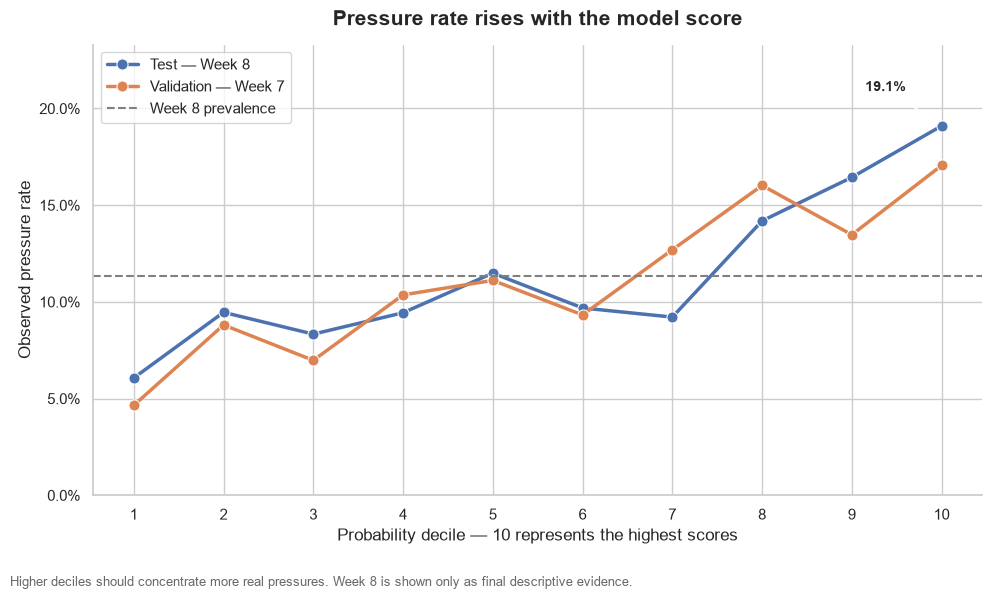

,check_id,area,observed,expected,status
0,ST9-82,Chart datasets,2,2,PASS
1,ST9-83,Chart decile rows,20,20,PASS
2,ST9-84,Chart exported,True,True,PASS
3,ST9-85,Locked model unchanged,True,True,PASS


STAGE 9 FINAL DECILE VISUALIZATION: PASS
CHART: reports\stage9_decile_stability.png
CHART SHA-256: 5e79be3c59c817e8494033972d700f3413046812a83d89cc4ae33bbce741a989
NO MODEL OR THRESHOLD CHANGE PERFORMED


In [13]:
# ETAPA 9 · CELDA 14 — Visualización de estabilidad por deciles

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter


decile_plot_data = combined_deciles[
    [
        "dataset",
        "probability_decile",
        "observed_pressure_rate",
    ]
].copy()

decile_plot_data["dataset_label"] = (
    decile_plot_data["dataset"].map(
        {
            "validation_week_7": "Validation — Week 7",
            "test_week_8": "Test — Week 8",
        }
    )
)

decile_plot_data = decile_plot_data.sort_values(
    ["dataset_label", "probability_decile"]
)

PATHS["decile_stability_chart"] = (
    PROJECT_ROOT
    / "reports"
    / "stage9_decile_stability.png"
)

sns.set_theme(
    style="whitegrid",
    context="notebook",
)

figure, axis = plt.subplots(
    figsize=(10, 6)
)

sns.lineplot(
    data=decile_plot_data,
    x="probability_decile",
    y="observed_pressure_rate",
    hue="dataset_label",
    marker="o",
    linewidth=2.5,
    markersize=8,
    errorbar=None,
    ax=axis,
)

test_positive_rate = final_metric_values[
    "actual_positive_rate"
]

axis.axhline(
    test_positive_rate,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Week 8 prevalence",
)

test_top_decile_rate = float(
    test_deciles_final.loc[
        test_deciles_final[
            "probability_decile"
        ].eq(10),
        "observed_pressure_rate",
    ].iloc[0]
)

axis.annotate(
    f"{test_top_decile_rate:.1%}",
    xy=(10, test_top_decile_rate),
    xytext=(9.15, test_top_decile_rate + 0.018),
    arrowprops={
        "arrowstyle": "->",
        "linewidth": 1.2,
    },
    fontsize=10,
    fontweight="bold",
)

axis.set_title(
    "Pressure rate rises with the model score",
    fontsize=15,
    fontweight="bold",
    pad=14,
)

axis.set_xlabel(
    "Probability decile — 10 represents the highest scores"
)
axis.set_ylabel(
    "Observed pressure rate"
)

axis.set_xticks(range(1, 11))
axis.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)
axis.set_ylim(
    0,
    decile_plot_data[
        "observed_pressure_rate"
    ].max() * 1.22,
)

axis.legend(
    title=None,
    frameon=True,
    loc="upper left",
)

sns.despine(
    fig=figure,
    ax=axis,
)

figure.text(
    0.01,
    0.01,
    (
        "Higher deciles should concentrate more real pressures. "
        "Week 8 is shown only as final descriptive evidence."
    ),
    fontsize=9,
    color="dimgray",
)

figure.tight_layout(
    rect=[0, 0.05, 1, 1]
)

figure.savefig(
    PATHS["decile_stability_chart"],
    dpi=180,
    bbox_inches="tight",
)

plt.show()

decile_chart_sha256 = calculate_sha256(
    PATHS["decile_stability_chart"]
)

chart_quality_checks = pd.DataFrame(
    [
        {
            "check_id": "ST9-82",
            "area": "Chart datasets",
            "observed": (
                decile_plot_data[
                    "dataset_label"
                ].nunique()
            ),
            "expected": 2,
        },
        {
            "check_id": "ST9-83",
            "area": "Chart decile rows",
            "observed": len(decile_plot_data),
            "expected": 20,
        },
        {
            "check_id": "ST9-84",
            "area": "Chart exported",
            "observed": (
                PATHS[
                    "decile_stability_chart"
                ].is_file()
            ),
            "expected": True,
        },
        {
            "check_id": "ST9-85",
            "area": "Locked model unchanged",
            "observed": (
                calculate_sha256(
                    PATHS["final_model"]
                ) == final_model_sha256
            ),
            "expected": True,
        },
    ]
)

chart_quality_checks["status"] = np.where(
    chart_quality_checks["observed"]
    == chart_quality_checks["expected"],
    "PASS",
    "FAIL",
)

display(chart_quality_checks)

assert chart_quality_checks[
    "status"
].eq("PASS").all()

print("STAGE 9 FINAL DECILE VISUALIZATION: PASS")
print(
    "CHART:",
    PATHS["decile_stability_chart"]
    .relative_to(PROJECT_ROOT),
)
print("CHART SHA-256:", decile_chart_sha256)
print(
    "NO MODEL OR THRESHOLD CHANGE PERFORMED"
)

In [14]:
# ETAPA 9 · CELDA 15 — Exportación final y reporte de calidad

if globals().get("final_export_completed", False):
    raise RuntimeError(
        "Los artefactos finales ya fueron exportados en este kernel."
    )

assert final_test_evaluation_completed is True
assert calculate_sha256(
    PATHS["final_model"]
) == final_model_sha256
assert np.isclose(
    locked_threshold,
    threshold_contract["threshold"],
    rtol=0.0,
    atol=1e-15,
)

PATHS.update(
    {
        "test_predictions": (
            PROJECT_ROOT
            / "reports"
            / "stage9_test_predictions.parquet"
        ),
        "test_metrics": (
            PROJECT_ROOT
            / "reports"
            / "stage9_test_metrics.csv"
        ),
        "confusion_matrix": (
            PROJECT_ROOT
            / "reports"
            / "stage9_confusion_matrix.csv"
        ),
        "validation_test_comparison": (
            PROJECT_ROOT
            / "reports"
            / "stage9_validation_test_comparison.csv"
        ),
        "confusion_comparison": (
            PROJECT_ROOT
            / "reports"
            / "stage9_confusion_comparison.csv"
        ),
        "average_precision_lift": (
            PROJECT_ROOT
            / "reports"
            / "stage9_average_precision_lift.csv"
        ),
        "test_deciles": (
            PROJECT_ROOT
            / "reports"
            / "stage9_test_deciles.csv"
        ),
        "calibration_summary": (
            PROJECT_ROOT
            / "reports"
            / "stage9_calibration_summary.csv"
        ),
        "final_quality_report": (
            PROJECT_ROOT
            / "reports"
            / "stage9_final_quality_report.csv"
        ),
        "final_manifest": (
            PROJECT_ROOT
            / "reports"
            / "stage9_final_manifest.json"
        ),
    }
)


def atomic_write_csv(dataframe, destination):
    temporary_path = destination.with_suffix(
        ".tmp.csv"
    )
    dataframe.to_csv(
        temporary_path,
        index=False,
        lineterminator="\n",
    )
    temporary_path.replace(destination)


def atomic_write_parquet(dataframe, destination):
    temporary_path = destination.with_suffix(
        ".tmp.parquet"
    )
    dataframe.to_parquet(
        temporary_path,
        index=False,
        engine="pyarrow",
        compression="snappy",
    )
    temporary_path.replace(destination)


atomic_write_parquet(
    test_predictions,
    PATHS["test_predictions"],
)
atomic_write_csv(
    final_test_metrics,
    PATHS["test_metrics"],
)
atomic_write_csv(
    final_confusion_matrix,
    PATHS["confusion_matrix"],
)
atomic_write_csv(
    validation_test_comparison,
    PATHS["validation_test_comparison"],
)
atomic_write_csv(
    confusion_comparison,
    PATHS["confusion_comparison"],
)
atomic_write_csv(
    average_precision_lift,
    PATHS["average_precision_lift"],
)
atomic_write_csv(
    test_deciles_final,
    PATHS["test_deciles"],
)
atomic_write_csv(
    calibration_summary,
    PATHS["calibration_summary"],
)

export_verification = pd.DataFrame(
    [
        {
            "artifact": "test_predictions",
            "observed_shape": pd.read_parquet(
                PATHS["test_predictions"]
            ).shape,
            "expected_shape": (4444, 10),
        },
        {
            "artifact": "test_metrics",
            "observed_shape": pd.read_csv(
                PATHS["test_metrics"]
            ).shape,
            "expected_shape": (9, 2),
        },
        {
            "artifact": "confusion_matrix",
            "observed_shape": pd.read_csv(
                PATHS["confusion_matrix"]
            ).shape,
            "expected_shape": (2, 3),
        },
        {
            "artifact": "validation_test_comparison",
            "observed_shape": pd.read_csv(
                PATHS["validation_test_comparison"]
            ).shape,
            "expected_shape": (9, 6),
        },
        {
            "artifact": "confusion_comparison",
            "observed_shape": pd.read_csv(
                PATHS["confusion_comparison"]
            ).shape,
            "expected_shape": (4, 3),
        },
        {
            "artifact": "average_precision_lift",
            "observed_shape": pd.read_csv(
                PATHS["average_precision_lift"]
            ).shape,
            "expected_shape": (2, 4),
        },
        {
            "artifact": "test_deciles",
            "observed_shape": pd.read_csv(
                PATHS["test_deciles"]
            ).shape,
            "expected_shape": (10, 9),
        },
        {
            "artifact": "calibration_summary",
            "observed_shape": pd.read_csv(
                PATHS["calibration_summary"]
            ).shape,
            "expected_shape": (2, 7),
        },
    ]
)

export_verification["status"] = np.where(
    export_verification["observed_shape"]
    == export_verification["expected_shape"],
    "PASS",
    "FAIL",
)

quality_sources = [
    protocol_check_report,
    development_check_report,
    validation_checkpoint_report,
    probability_reproduction_check,
    final_training_check,
    pretest_lock_report,
    test_contract_report,
    final_evaluation_checks,
    decile_quality_checks,
    chart_quality_checks,
]

final_quality_report = pd.concat(
    [
        source[
            [
                "check_id",
                "area",
                "observed",
                "expected",
                "status",
            ]
        ].copy()
        for source in quality_sources
    ],
    ignore_index=True,
)

additional_quality_checks = pd.DataFrame(
    [
        {
            "check_id": "ST9-86",
            "area": "Environment versions",
            "observed": int(
                environment_check[
                    "status"
                ].eq("PASS").sum()
            ),
            "expected": 5,
            "status": (
                "PASS"
                if environment_check[
                    "status"
                ].eq("PASS").all()
                else "FAIL"
            ),
        },
        {
            "check_id": "ST9-87",
            "area": "Required artifact presence",
            "observed": int(
                artifact_inventory[
                    "exists"
                ].sum()
            ),
            "expected": 6,
            "status": (
                "PASS"
                if artifact_inventory[
                    "exists"
                ].all()
                else "FAIL"
            ),
        },
        {
            "check_id": "ST9-88",
            "area": "Locked artifact hashes",
            "observed": int(
                integrity_check[
                    "status"
                ].eq("PASS").sum()
            ),
            "expected": 4,
            "status": (
                "PASS"
                if integrity_check[
                    "status"
                ].eq("PASS").all()
                else "FAIL"
            ),
        },
        {
            "check_id": "ST9-89",
            "area": "Validation metric reproduction",
            "observed": int(
                metric_reproduction[
                    "status"
                ].eq("PASS").sum()
            ),
            "expected": 3,
            "status": (
                "PASS"
                if metric_reproduction[
                    "status"
                ].eq("PASS").all()
                else "FAIL"
            ),
        },
        {
            "check_id": "ST9-90",
            "area": "Final tabular exports",
            "observed": int(
                export_verification[
                    "status"
                ].eq("PASS").sum()
            ),
            "expected": 8,
            "status": (
                "PASS"
                if export_verification[
                    "status"
                ].eq("PASS").all()
                else "FAIL"
            ),
        },
        {
            "check_id": "ST9-91",
            "area": "Final model hash",
            "observed": calculate_sha256(
                PATHS["final_model"]
            ),
            "expected": final_model_sha256,
            "status": (
                "PASS"
                if calculate_sha256(
                    PATHS["final_model"]
                ) == final_model_sha256
                else "FAIL"
            ),
        },
        {
            "check_id": "ST9-92",
            "area": "Final threshold",
            "observed": locked_threshold,
            "expected": (
                threshold_contract["threshold"]
            ),
            "status": (
                "PASS"
                if np.isclose(
                    locked_threshold,
                    threshold_contract["threshold"],
                    rtol=0.0,
                    atol=1e-15,
                )
                else "FAIL"
            ),
        },
        {
            "check_id": "ST9-93",
            "area": "Week 8 materializations",
            "observed": (
                week_8_materialization_count
            ),
            "expected": 1,
            "status": (
                "PASS"
                if week_8_materialization_count == 1
                else "FAIL"
            ),
        },
    ]
)

final_quality_report = pd.concat(
    [
        final_quality_report,
        additional_quality_checks,
    ],
    ignore_index=True,
)

final_quality_report["check_number"] = (
    final_quality_report["check_id"]
    .str.split("-")
    .str[-1]
    .astype(int)
)

final_quality_report = (
    final_quality_report
    .sort_values("check_number")
    .drop(columns="check_number")
    .reset_index(drop=True)
)

assert len(final_quality_report) == 93
assert final_quality_report[
    "check_id"
].is_unique
assert final_quality_report[
    "status"
].eq("PASS").all()

atomic_write_csv(
    final_quality_report,
    PATHS["final_quality_report"],
)

final_quality_sha256 = calculate_sha256(
    PATHS["final_quality_report"]
)

manifest_artifact_keys = [
    "final_model",
    "pretest_manifest",
    "test_predictions",
    "test_metrics",
    "confusion_matrix",
    "validation_test_comparison",
    "confusion_comparison",
    "average_precision_lift",
    "test_deciles",
    "calibration_summary",
    "decile_stability_chart",
    "final_quality_report",
]

final_artifact_inventory = [
    {
        "artifact": artifact,
        "path": PATHS[artifact]
        .relative_to(PROJECT_ROOT)
        .as_posix(),
        "size_bytes": PATHS[artifact].stat().st_size,
        "sha256": calculate_sha256(
            PATHS[artifact]
        ),
    }
    for artifact in manifest_artifact_keys
]

final_manifest = {
    "project": "nfl-pressure-prediction",
    "stage": 9,
    "status": (
        "final_test_evaluation_completed_"
        "without_post_test_adjustment"
    ),
    "source_commit": "4a4c650",
    "test_contract": {
        "week": 8,
        "rows": len(test_predictions),
        "plays": len(test_play_keys),
        "positives": int(y_test.sum()),
        "materialization_count": (
            week_8_materialization_count
        ),
    },
    "model_contract": {
        "path": PATHS["final_model"]
        .relative_to(PROJECT_ROOT)
        .as_posix(),
        "sha256": final_model_sha256,
        "training_weeks": final_training_weeks,
        "feature_count": len(
            ordered_feature_names
        ),
        "threshold": locked_threshold,
    },
    "final_metrics": {
        metric: float(value)
        for metric, value
        in final_metric_values.items()
    },
    "confusion_matrix": {
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
    },
    "quality": {
        "checks": len(final_quality_report),
        "passes": int(
            final_quality_report[
                "status"
            ].eq("PASS").sum()
        ),
        "failures": int(
            final_quality_report[
                "status"
            ].eq("FAIL").sum()
        ),
        "report_sha256": final_quality_sha256,
    },
    "post_test_adjustments": {
        "model": False,
        "features": False,
        "hyperparameters": False,
        "threshold": False,
        "calibration": False,
    },
    "artifacts": final_artifact_inventory,
}

temporary_final_manifest = (
    PATHS["final_manifest"].with_suffix(
        ".tmp.json"
    )
)

with temporary_final_manifest.open(
    "w",
    encoding="utf-8",
    newline="\n",
) as file:
    json.dump(
        final_manifest,
        file,
        indent=2,
        sort_keys=True,
        ensure_ascii=False,
    )
    file.write("\n")

temporary_final_manifest.replace(
    PATHS["final_manifest"]
)

final_manifest_sha256 = calculate_sha256(
    PATHS["final_manifest"]
)

display(export_verification)
display(
    final_quality_report[
        "status"
    ].value_counts().rename_axis(
        "status"
    ).reset_index(name="checks")
)
display(pd.DataFrame(final_artifact_inventory))

assert PATHS["final_manifest"].is_file()
assert calculate_sha256(
    PATHS["final_model"]
) == final_model_sha256

final_export_completed = True

print("STAGE 9 FINAL EXPORT AND QUALITY REPORT: PASS")
print("QUALITY CONTROLS: 93/93 PASS")
print(
    "FINAL QUALITY SHA-256:",
    final_quality_sha256,
)
print(
    "FINAL MANIFEST SHA-256:",
    final_manifest_sha256,
)
print(
    "POST-TEST ADJUSTMENTS:",
    final_manifest["post_test_adjustments"],
)

,artifact,observed_shape,expected_shape,status
0,test_predictions,"(4444, 10)","(4444, 10)",PASS
1,test_metrics,"(9, 2)","(9, 2)",PASS
2,confusion_matrix,"(2, 3)","(2, 3)",PASS
3,validation_test_comparison,"(9, 6)","(9, 6)",PASS
4,confusion_comparison,"(4, 3)","(4, 3)",PASS
5,average_precision_lift,"(2, 4)","(2, 4)",PASS
6,test_deciles,"(10, 9)","(10, 9)",PASS
7,calibration_summary,"(2, 7)","(2, 7)",PASS


,status,checks
0,PASS,93


,artifact,path,size_bytes,sha256
0,final_model,models/stage9_final_model.joblib,4070,d073466a12a72378bb2e7ecaba43563307d207e876ea54...
1,pretest_manifest,reports/stage9_pretest_manifest.json,3784,50b78d6ebf64b8e527ac617a4c06a8888c11a2a7d3cdfb...
2,test_predictions,reports/stage9_test_predictions.parquet,69103,fb03df6fb64bb01cb04d359a13cf7157fb8acd191a8549...
3,test_metrics,reports/stage9_test_metrics.csv,302,fa218dc4b5074c786496bec348ab7cf7c8170264ed0184...
4,confusion_matrix,reports/stage9_confusion_matrix.csv,59,29721427824d7f0f772632a292b35ca99487dcf3688821...
5,validation_test_comparison,reports/stage9_validation_test_comparison.csv,1077,b8d404ce7527c580361e3fa66b7ed2f848e5e55ee8b8eb...
6,confusion_comparison,reports/stage9_confusion_comparison.csv,132,6834f0e7156355eba8682e232c1d0615f6e8cf7d32c474...
7,average_precision_lift,reports/stage9_average_precision_lift.csv,206,4b91d00560f93bf44f9a4ad0fd7d7eb80f0239cc50f4c5...
8,test_deciles,reports/stage9_test_deciles.csv,1337,9ac1e293a3ac39db8433f4c3e502a8c73e61f5c4cde9c7...
9,calibration_summary,reports/stage9_calibration_summary.csv,350,38ff4a59b01fd0642827efbd57796863440b702556e6e3...


STAGE 9 FINAL EXPORT AND QUALITY REPORT: PASS
QUALITY CONTROLS: 93/93 PASS
FINAL QUALITY SHA-256: 2bf5cda51e4b629f730b23f4b7098300bd02dd9f0edc0c9c264e51e5f63b1863
FINAL MANIFEST SHA-256: e9c0728cddeb674798685304ded85ea04b144fb2022de510179520e78db6c1ab
POST-TEST ADJUSTMENTS: {'model': False, 'features': False, 'hyperparameters': False, 'threshold': False, 'calibration': False}


# Resultados y conclusiones de la evaluación final

## Resultados sobre la semana 8

La evaluación final se realizó sobre 4,444 combinaciones de pass rusher y jugada, pertenecientes a 1,031 jugadas. Se observaron 504 presiones reales, equivalentes a una prevalencia de 11.34%.

| Métrica | Resultado |
|---|---:|
| Average Precision | 0.157750 |
| ROC-AUC | 0.596890 |
| Log Loss | 0.347812 |
| Precision | 0.158940 |
| Recall | 0.476190 |
| F1 | 0.238332 |
| Specificity | 0.677665 |
| Tasa predicha de presión | 33.98% |
| Tasa real de presión | 11.34% |

Matriz de confusión:

| Resultado | Casos |
|---|---:|
| True Negative | 2,670 |
| False Positive | 1,270 |
| False Negative | 264 |
| True Positive | 240 |

En términos sencillos, el modelo identificó 240 de las 504 presiones reales. Esto representa un recall de 47.62%. Sin embargo, de los 1,510 casos clasificados como presión, solo 240 fueron correctos, por lo que la precision fue de 15.89%.

## Generalización temporal

El comportamiento de la semana 8 fue similar al observado en la semana 7:

- Average Precision aumentó de 0.151899 a 0.157750.
- ROC-AUC disminuyó ligeramente de 0.600006 a 0.596890.
- F1 permaneció prácticamente estable: 0.237102 frente a 0.238332.
- Recall disminuyó de 50.59% a 47.62%.
- Specificity aumentó de 65.71% a 67.77%.

No se observó un colapso de desempeño al avanzar hacia una semana futura. Esto aporta evidencia de estabilidad temporal, aunque la capacidad discriminativa continúa siendo modesta.

## Ranking y calibración

La Average Precision del test fue 1.391 veces la prevalencia de presión. Además, el decil con las probabilidades más altas alcanzó una tasa de presión de 19.10%, equivalente a un lift de 1.684 veces la prevalencia.

La probabilidad promedio estimada fue 11.53%, frente a una tasa real de 11.34%. Esta cercanía indica una calibración agregada razonable, aunque no garantiza calibración perfecta en todos los rangos de probabilidad.

## Interpretación operativa

El modelo funciona mejor como una herramienta de ranking o priorización que como un detector automático de alta precisión. Permite concentrar más presiones reales entre los jugadores con scores altos, pero el threshold seleccionado produce numerosas falsas alarmas.

El threshold de `0.12485514806532311` fue elegido exclusivamente en la semana 7 para maximizar F1. No fue modificado después de observar los resultados finales.

## Limitaciones

- El análisis utiliza únicamente las semanas 1–8 disponibles, por lo que no demuestra estabilidad durante una temporada completa.
- Varias filas pueden pertenecer a una misma jugada; por ello, las observaciones no son completamente independientes dentro de cada jugada.
- El target combina hurry, hit y sack en una sola clase binaria y no distingue la gravedad de cada resultado.
- Las variables utilizan únicamente información disponible en el snap y no incorporan el desarrollo posterior de la jugada.
- La regresión logística prioriza estabilidad e interpretabilidad, pero puede no capturar relaciones no lineales e interacciones complejas.
- El elevado número de falsos positivos limita su uso como sistema de decisión autónomo.

## Conclusión

La regresión logística seleccionada proporciona un baseline interpretable y temporalmente estable para estimar la probabilidad de presión de cada pass rusher desde el snap. Su desempeño supera al baseline asociado con la prevalencia y mantiene resultados consistentes en la semana futura.

El modelo es útil para ordenar o priorizar situaciones de mayor riesgo, pero requiere mejoras adicionales antes de utilizarse como un detector de alta precisión. No se realizaron ajustes del modelo, variables, hiperparámetros, calibración ni threshold después de acceder al conjunto de prueba.